# Climate Data Analysis: Rainfall and Temperature Trends

This notebook analyzes climate data including rainfall, minimum and maximum temperatures across different regions. The data comes from multiple Excel files that need to be cleaned, merged, and analyzed.

## Data Description
The dataset contains:
- Rainfall measurements by district, station, year, month and week
- Minimum temperatures by region, year, month and week
- Maximum temperatures by region, year, month and week

The data covers multiple years and needs to be standardized before analysis.

In [41]:

import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set visualization style
sns.set_style("darkgrid")
sns.set_palette("husl")


## Step 1: Data Loading and Initial Cleaning

We'll start by creating a function to clean and standardize the Excel files. Each file contains:
- District and station information in the first few rows
- Yearly data organized in blocks of 5 rows per year
- Monthly and weekly measurements

In [42]:

def clean_climate_data(file_path, output_column_name):
    """
    Cleans climate data Excel files and returns a standardized DataFrame.
    
    Parameters:
    - file_path: Path to Excel file
    - output_column_name: Name for the measurement column (e.g., 'Rainfall')
    
    Returns:
    - DataFrame with District, Station, Year, Month, Week, and measurement columns
    """
    # Read Excel file without assuming headers
    raw_df = pd.read_excel(file_path, header=None)
    
    # Initialize district and station variables
    district = station = None
    
    # Search first 5 rows and columns for district/station info
    for i in range(5):
        for j in range(5):
            cell_value = str(raw_df.iloc[i, j])
            if 'District' in cell_value:
                district = cell_value.split(':')[-1].strip() if ':' in cell_value else 'Unknown'
            if 'Station' in cell_value:
                station = cell_value.split(':')[-1].strip() if ':' in cell_value else 'Unknown'
    
    # Fallback if district not found
    district = district if district else station
    
    # Process yearly data blocks
    cleaned_rows = []
    current_row = 0
    
    while current_row < len(raw_df):
        row_data = raw_df.iloc[current_row]
        first_cell = str(row_data.iloc[0]).strip()
        
        # Check if row starts a new year block (4-digit year)
        if re.match(r'^\d{4}$', first_cell):
            year = int(first_cell)
            months = raw_df.iloc[current_row].iloc[1:13].tolist()
            weekly_data = raw_df.iloc[current_row+1:current_row+5].reset_index(drop=True)
            
            # Process each week (4 weeks per month)
            for week_number in range(4):
                week_label = weekly_data.iloc[week_number, 0]
                for month_idx in range(12):
                    month_name = months[month_idx]
                    measurement = weekly_data.iloc[week_number, month_idx + 1]
                    
                    cleaned_rows.append({
                        'District': district,
                        'Station': station,
                        'Year': year,
                        'Month': month_name,
                        'Week': week_label,
                        output_column_name: measurement
                    })
            
            current_row += 5  # Skip to next year block
        else:
            current_row += 1  # Move to next row
    
    return pd.DataFrame(cleaned_rows)



## Step 2: Processing Rainfall Data

We'll process all rainfall Excel files in the specified directory and combine them into a single DataFrame.


In [43]:

# Configuration
RAINFALL_DIR = '../RawDataset/rainfall'
rainfall_data_frames = []

# Process each rainfall file
print("Processing rainfall data files:")
for filename in os.listdir(RAINFALL_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(RAINFALL_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Rainfall")
        rainfall_data_frames.append(df)

# Combine all rainfall data
combined_rainfall_df = pd.concat(rainfall_data_frames, ignore_index=True)

# Save combined data
rainfall_output_path = '../RawDataset/rainfall/combined_rainfall_data.csv'
combined_rainfall_df.to_csv(rainfall_output_path, index=False)
print(f"\nSaved combined rainfall data to {rainfall_output_path}")

# Show sample data
print("\nSample rainfall data:")
combined_rainfall_df.head()

Processing rainfall data files:
- rain_unguja_magharibi_b.xlsx
- WETE.xlsx
- rain_unguja_kusini.xlsx
- mjini.xlsx
- Micheweni.xlsx
- rain_unguja_kas_b.xlsx
- rain_unguja_magharibi_a.xlsx
- rain_unguja_kas_a.xlsx
- Mkoani.xlsx
- Chake-Chake.xlsx

Saved combined rainfall data to ../RawDataset/rainfall/combined_rainfall_data.csv

Sample rainfall data:


,District,Station,Year,Month,Week,Rainfall
0,Zanzibar Airport,Zanzibar Airport,2023,Jan,1st week,3.8
1,Zanzibar Airport,Zanzibar Airport,2023,Feb,1st week,0.0
2,Zanzibar Airport,Zanzibar Airport,2023,Mar,1st week,0.0
3,Zanzibar Airport,Zanzibar Airport,2023,Apr,1st week,51.6
4,Zanzibar Airport,Zanzibar Airport,2023,May,1st week,69.6



### Rainfall Data Visualization

Let's visualize the distribution of rainfall measurements across different regions and years.


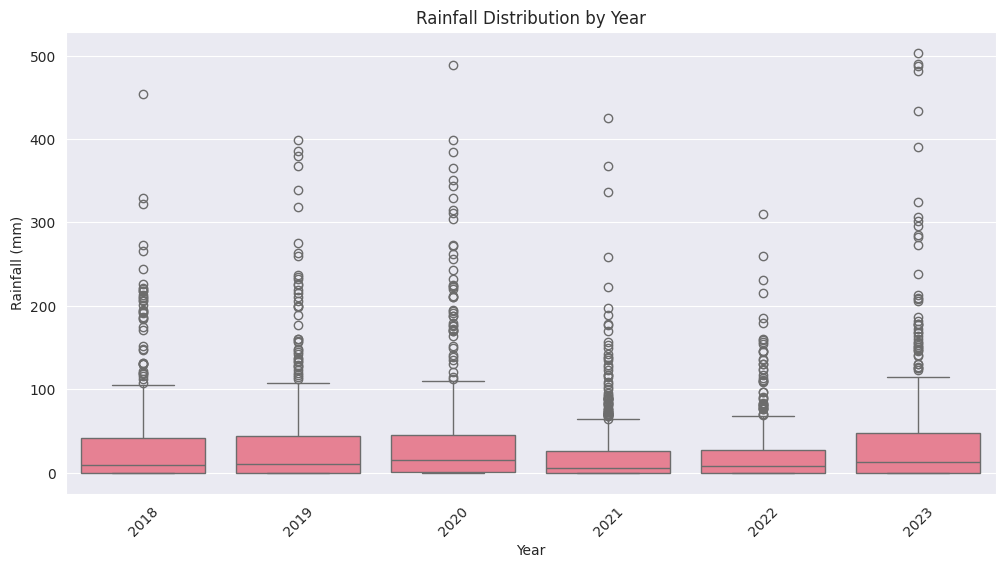

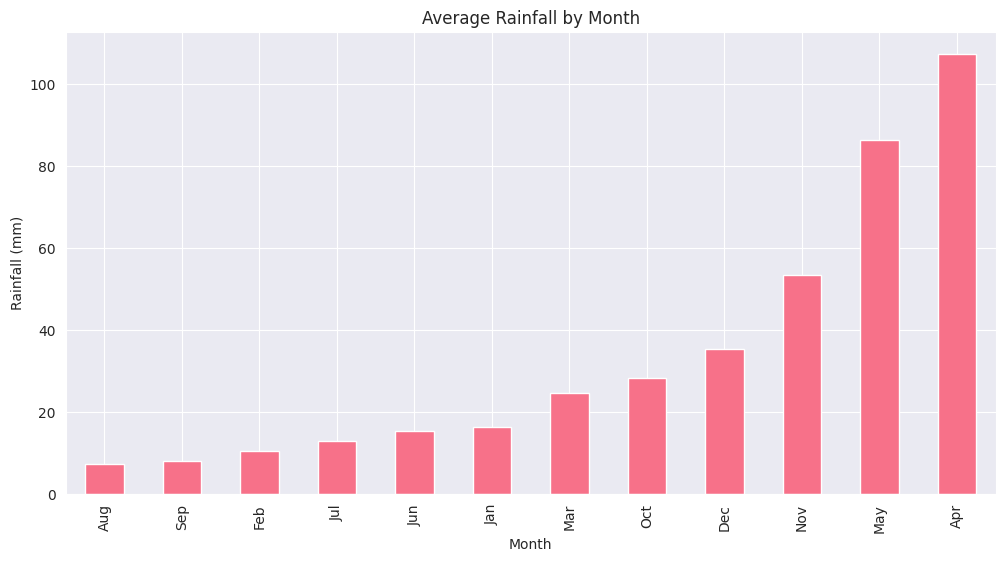

In [44]:

# Plot rainfall distribution by year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Rainfall', data=combined_rainfall_df)
plt.title('Rainfall Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Rainfall (mm)')
plt.show()

# Plot average rainfall by month
plt.figure(figsize=(12, 6))
combined_rainfall_df.groupby('Month')['Rainfall'].mean().sort_values().plot(kind='bar')
plt.title('Average Rainfall by Month')
plt.ylabel('Rainfall (mm)')
plt.show()



## Step 3: Processing Temperature Data

We'll process both minimum and maximum temperature data similarly to the rainfall data.


In [45]:

# Process maximum temperature data
MAX_TEMP_DIR = '../RawDataset/temperatures/max_temp'
max_temp_data_frames = []

print("\nProcessing maximum temperature data files:")
for filename in os.listdir(MAX_TEMP_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(MAX_TEMP_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Max Temperature")
        max_temp_data_frames.append(df)

combined_max_temp_df = pd.concat(max_temp_data_frames, ignore_index=True)
max_temp_output_path = '../RawDataset/temperatures/max_temp/combined_max_temperature_data.csv'
combined_max_temp_df.to_csv(max_temp_output_path, index=False)
print(f"\nSaved combined max temperature data to {max_temp_output_path}")

# Process minimum temperature data
MIN_TEMP_DIR = '../RawDataset/temperatures/min_temp'
min_temp_data_frames = []

print("\nProcessing minimum temperature data files:")
for filename in os.listdir(MIN_TEMP_DIR):
    if filename.endswith('.xlsx'):
        file_path = os.path.join(MIN_TEMP_DIR, filename)
        print(f"- {filename}")
        df = clean_climate_data(file_path, "Min Temperature")
        min_temp_data_frames.append(df)

combined_min_temp_df = pd.concat(min_temp_data_frames, ignore_index=True)
min_temp_output_path = '../RawDataset/temperatures/min_temp/combined_min_temperature_data.csv'
combined_min_temp_df.to_csv(min_temp_output_path, index=False)
print(f"\nSaved combined min temperature data to {min_temp_output_path}")

# Show sample data
print("\nSample temperature data:")
print("Max Temperature:")
combined_max_temp_df.head()



Processing maximum temperature data files:
- unguja_max_temp.xlsx
- Maximum. t pemba.xlsx

Saved combined max temperature data to ../RawDataset/temperatures/max_temp/combined_max_temperature_data.csv

Processing minimum temperature data files:
- unguja_min_temp.xlsx
- MINIMUM pemba.xlsx

Saved combined min temperature data to ../RawDataset/temperatures/min_temp/combined_min_temperature_data.csv

Sample temperature data:
Max Temperature:


,District,Station,Year,Month,Week,Max Temperature
0,Zanzibar,Zanzibar,2023,Jan,1st week,32.142857
1,Zanzibar,Zanzibar,2023,Feb,1st week,33.357143
2,Zanzibar,Zanzibar,2023,Mar,1st week,33.914286
3,Zanzibar,Zanzibar,2023,Apr,1st week,31.585714
4,Zanzibar,Zanzibar,2023,May,1st week,30.885714


### Temperature Data Visualization

Visualizing temperature trends helps understand seasonal patterns and anomalies.


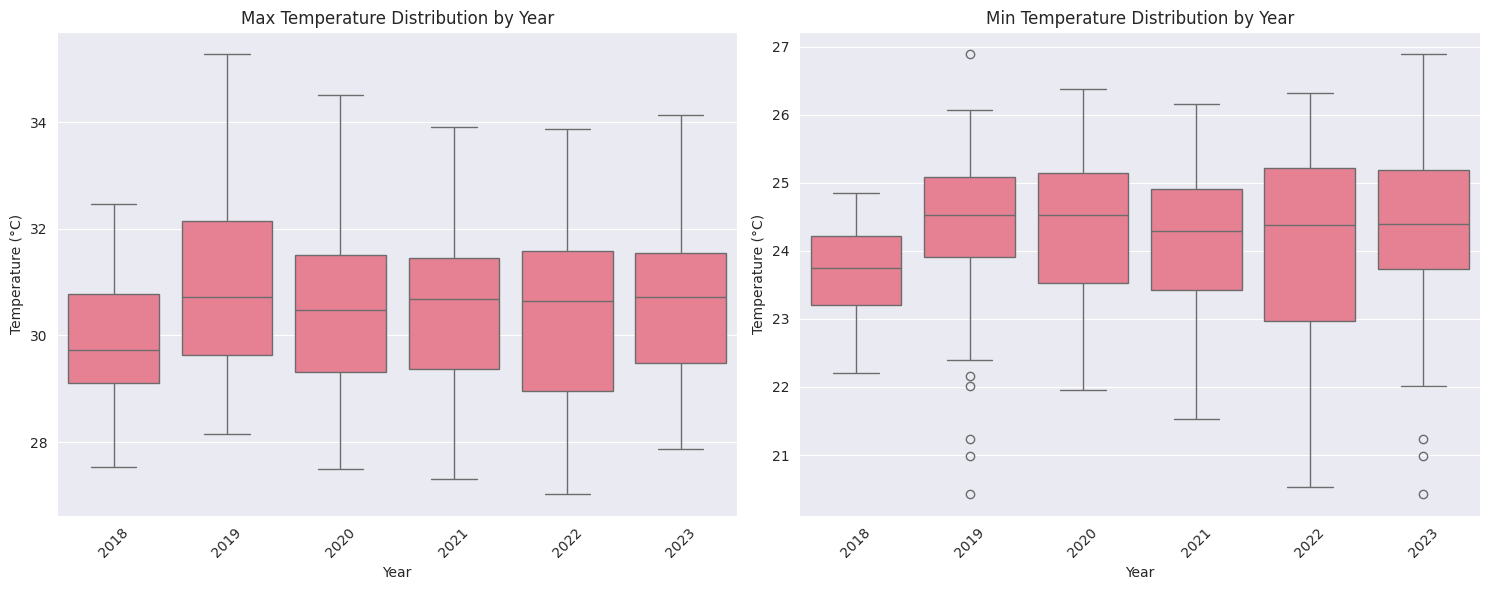

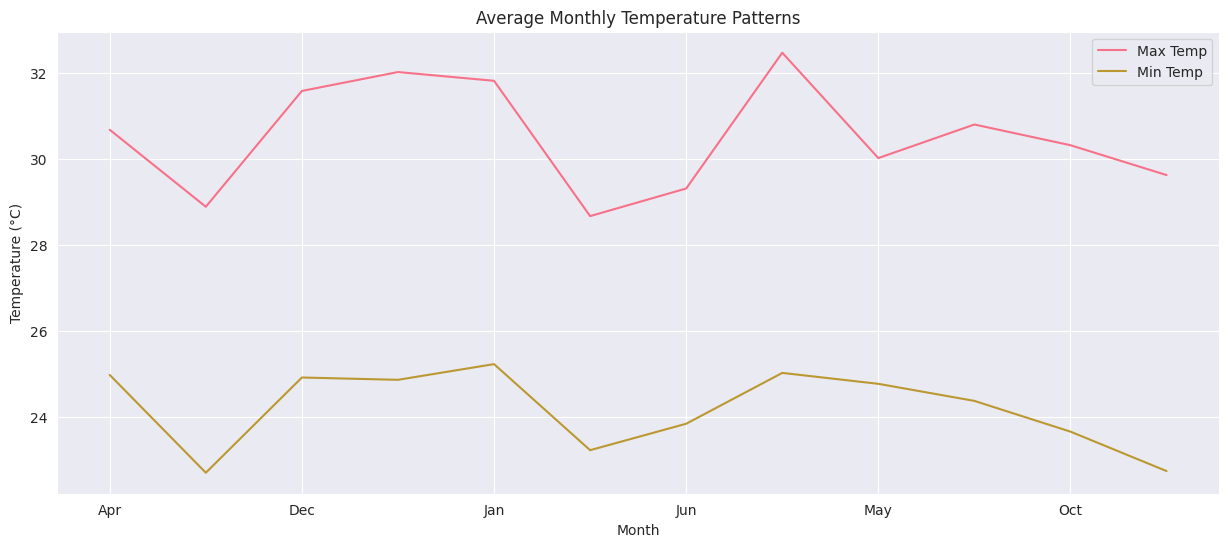

In [46]:

# Plot temperature trends
plt.figure(figsize=(15, 6))

# Max temperature by year
plt.subplot(1, 2, 1)
sns.boxplot(x='Year', y='Max Temperature', data=combined_max_temp_df)
plt.title('Max Temperature Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Temperature (°C)')

# Min temperature by year
plt.subplot(1, 2, 2)
sns.boxplot(x='Year', y='Min Temperature', data=combined_min_temp_df)
plt.title('Min Temperature Distribution by Year')
plt.xticks(rotation=45)
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

# Monthly temperature patterns
plt.figure(figsize=(15, 6))
combined_max_temp_df.groupby('Month')['Max Temperature'].mean().plot(label='Max Temp')
combined_min_temp_df.groupby('Month')['Min Temperature'].mean().plot(label='Min Temp')
plt.title('Average Monthly Temperature Patterns')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()



## Step 4: Data Integration and Region Mapping

We need to combine all datasets into a unified format and map districts to regions (Zanzibar, Pemba).


In [47]:
# Standardize temperature data frames
combined_max_temp_df["Region"] = combined_max_temp_df["Station"]
combined_max_temp_df.drop(["Station", "District"], axis=1, inplace=True)

combined_min_temp_df["Region"] = combined_min_temp_df["Station"]
combined_min_temp_df.drop(["Station", "District"], axis=1, inplace=True)

# Define region mapping
ZANZIBAR_DISTRICTS = ['WETE', 'MICHEWENI', 'CHAKE-CHAKE', 'MKOANI']
PEMBA_DISTRICTS = ['MAGHARIBI  B', 'KUSINI', 'MJINI', 'KASKAZINI B', 'MAGHARIBI  A', 'KASKAZINI A']

def map_to_region(district):
    """Maps district name to broader region (Zanzibar/Pemba)."""
    if pd.isna(district):
        return 'Unknown'
    district_upper = district.upper()
    if district_upper in [d.upper() for d in ZANZIBAR_DISTRICTS]:
        return 'Zanzibar'
    elif district_upper in [d.upper() for d in PEMBA_DISTRICTS]:
        return 'Pemba'
    return 'Unknown'

# Apply region mapping to rainfall data
combined_rainfall_df['Region'] = combined_rainfall_df['District'].apply(map_to_region)

# Merge temperature data
temperature_combined_df = pd.merge(
    combined_max_temp_df,
    combined_min_temp_df,
    on=['Year', 'Month', 'Week'],
    how='outer'
)

# Final merge with rainfall data
climate_combined_df = pd.merge(
    combined_rainfall_df,
    temperature_combined_df,
    on=['Year', 'Month', 'Week'],
    how='left'
)

# Save final combined data
final_output_path = '../RawDataset/rainfall_temperature.csv'
climate_combined_df.to_csv(final_output_path, index=False)
print(f"\nSaved final combined climate data to {final_output_path}")

# Show final data structure
print("\nFinal combined data structure:")
climate_combined_df.info()
climate_combined_df.head()



Saved final combined climate data to ../RawDataset/rainfall_temperature.csv

Final combined data structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         10080 non-null  object 
 1   Station          10080 non-null  object 
 2   Year             10080 non-null  int64  
 3   Month            10080 non-null  object 
 4   Week             10080 non-null  object 
 5   Rainfall         9840 non-null   float64
 6   Region           10080 non-null  object 
 7   Max Temperature  10080 non-null  float64
 8   Region_x         10080 non-null  object 
 9   Min Temperature  10080 non-null  float64
 10  Region_y         10080 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 866.4+ KB


,District,Station,Year,Month,Week,Rainfall,Region,Max Temperature,Region_x,Min Temperature,Region_y
0,Zanzibar Airport,Zanzibar Airport,2023,Jan,1st week,3.8,Unknown,32.142857,Zanzibar,26.885714,Zanzibar
1,Zanzibar Airport,Zanzibar Airport,2023,Jan,1st week,3.8,Unknown,32.142857,Zanzibar,25.200000,Pemba
2,Zanzibar Airport,Zanzibar Airport,2023,Jan,1st week,3.8,Unknown,32.114286,Pemba,26.885714,Zanzibar
3,Zanzibar Airport,Zanzibar Airport,2023,Jan,1st week,3.8,Unknown,32.114286,Pemba,25.200000,Pemba
4,Zanzibar Airport,Zanzibar Airport,2023,Feb,1st week,0.0,Unknown,33.357143,Zanzibar,25.042857,Zanzibar


### Combined Data Visualization

Visualizing relationships between rainfall and temperature across regions.

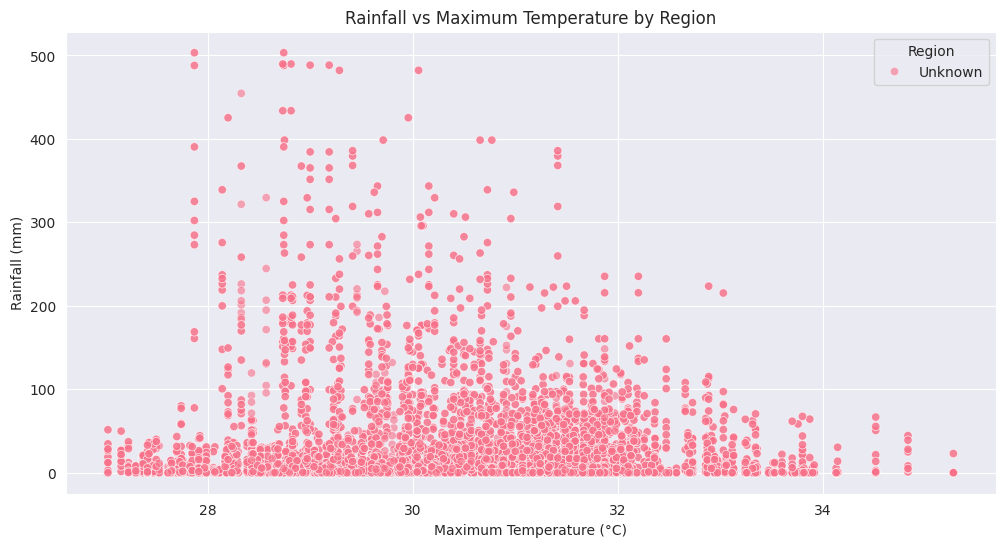

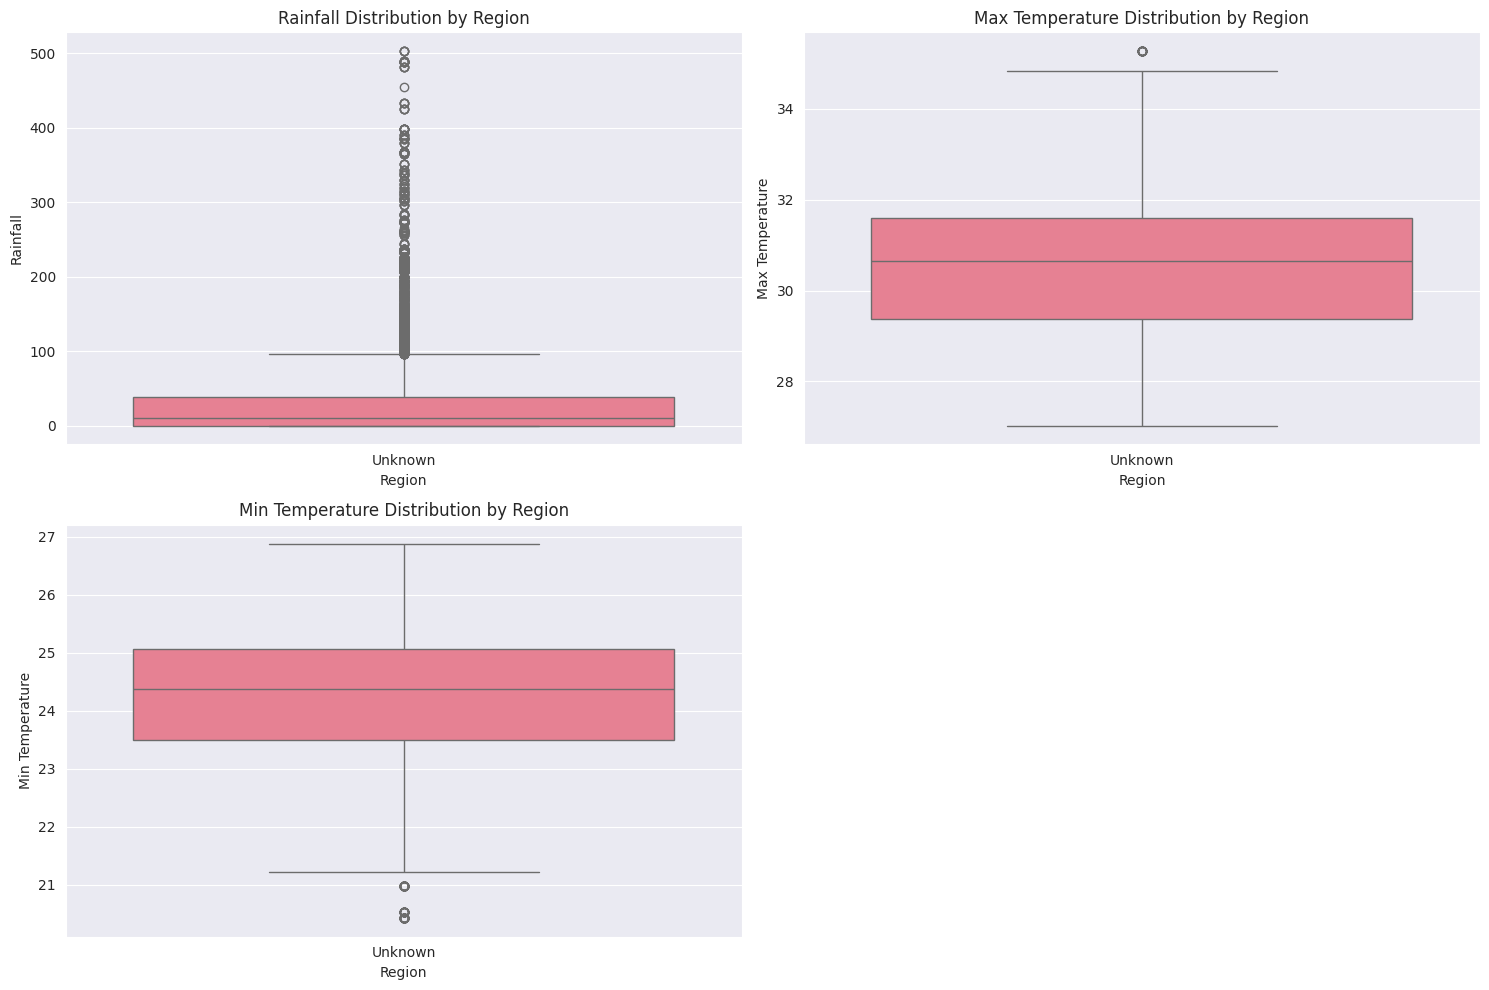

In [48]:

# Scatter plot of rainfall vs temperature
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Max Temperature', 
    y='Rainfall', 
    hue='Region', 
    data=climate_combined_df,
    alpha=0.6
)
plt.title('Rainfall vs Maximum Temperature by Region')
plt.xlabel('Maximum Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.show()

# Regional climate patterns
plt.figure(figsize=(15, 10))

# Rainfall by region
plt.subplot(2, 2, 1)
sns.boxplot(x='Region', y='Rainfall', data=climate_combined_df)
plt.title('Rainfall Distribution by Region')

# Max temp by region
plt.subplot(2, 2, 2)
sns.boxplot(x='Region', y='Max Temperature', data=climate_combined_df)
plt.title('Max Temperature Distribution by Region')

# Min temp by region
plt.subplot(2, 2, 3)
sns.boxplot(x='Region', y='Min Temperature', data=climate_combined_df)
plt.title('Min Temperature Distribution by Region')

plt.tight_layout()
plt.show()



## Step 5: Handling Missing Values (2018 Data)

For the year 2018, we'll predict missing temperature values using linear regression based on historical trends.


In [49]:

def predict_temperature(group_df, temperature_column):
    """
    Predicts temperature for 2018 using linear regression on historical data.
    
    Returns:
    - Predicted temperature or None if insufficient data
    """
    clean_df = group_df.dropna(subset=[temperature_column])
    if clean_df['Year'].nunique() < 2:
        return None  # Not enough data points
    
    model = LinearRegression()
    X = clean_df['Year'].values.reshape(-1, 1)
    y = clean_df[temperature_column].values
    model.fit(X, y)
    return model.predict([[2018]])[0]

# Process each district-month-week combination
for (district, month, week), group in climate_combined_df.groupby(['District', 'Month', 'Week']):
    # Find 2018 records for this group
    mask_2018 = (
        (climate_combined_df['Year'] == 2018) &
        (climate_combined_df['District'] == district) &
        (climate_combined_df['Month'] == month) &
        (climate_combined_df['Week'] == week)
    )
    
    if mask_2018.any():
        # Get historical data (excluding 2018)
        historical_data = climate_combined_df[
            (climate_combined_df['District'] == district) &
            (climate_combined_df['Month'] == month) &
            (climate_combined_df['Week'] == week) &
            (climate_combined_df['Year'] != 2018)
        ]
        
        # Predict missing values
        predicted_max = predict_temperature(historical_data, 'Max Temperature')
        predicted_min = predict_temperature(historical_data, 'Min Temperature')
        
        # Update DataFrame
        if predicted_max is not None:
            climate_combined_df.loc[mask_2018, 'Max Temperature'] = predicted_max
        if predicted_min is not None:
            climate_combined_df.loc[mask_2018, 'Min Temperature'] = predicted_min

print("Completed missing value imputation for 2018 data.")


Completed missing value imputation for 2018 data.



### Missing Data Analysis

Visualizing the impact of our missing value imputation.


Missing values in 2018 data:
- Before imputation: Max Temp - 0, Min Temp - 0
- After imputation: Max Temp - 0, Min Temp - 0


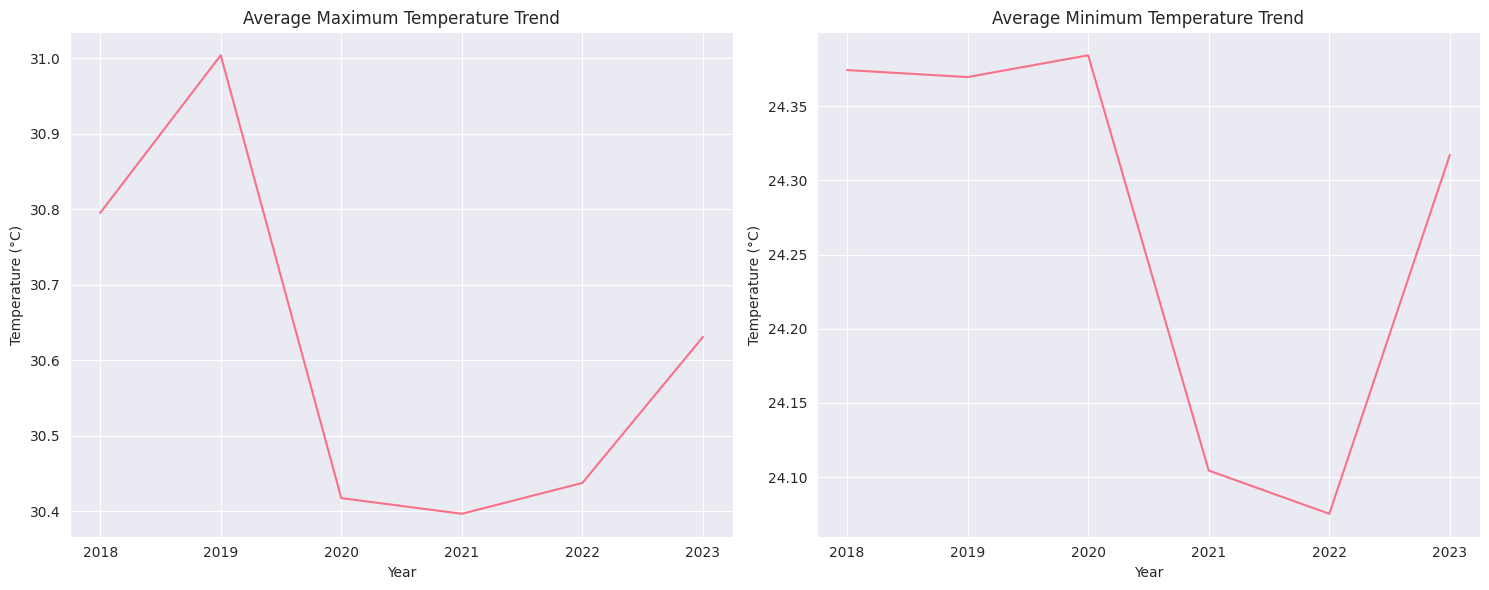

In [50]:

# Before and after missing value counts
missing_before = climate_combined_df[climate_combined_df['Year'] == 2018][
    ['Max Temperature', 'Min Temperature']
].isna().sum()

missing_after = climate_combined_df[climate_combined_df['Year'] == 2018][
    ['Max Temperature', 'Min Temperature']
].isna().sum()

print("Missing values in 2018 data:")
print(f"- Before imputation: Max Temp - {missing_before['Max Temperature']}, Min Temp - {missing_before['Min Temperature']}")
print(f"- After imputation: Max Temp - {missing_after['Max Temperature']}, Min Temp - {missing_after['Min Temperature']}")

# Plot temperature trends including imputed values
plt.figure(figsize=(15, 6))

# Max temperature trend
plt.subplot(1, 2, 1)
climate_combined_df.groupby('Year')['Max Temperature'].mean().plot()
plt.title('Average Maximum Temperature Trend')
plt.ylabel('Temperature (°C)')

# Min temperature trend
plt.subplot(1, 2, 2)
climate_combined_df.groupby('Year')['Min Temperature'].mean().plot()
plt.title('Average Minimum Temperature Trend')
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()



## Step 6: Final Data Export and Summary

The cleaned and processed data is now ready for analysis.


In [52]:

# Final data summary
print("\nFinal dataset summary:")
print(f"- Total records: {len(climate_combined_df)}")
print(f"- Time period: {climate_combined_df['Year'].min()} to {climate_combined_df['Year'].max()}")
print(f"- Regions: {climate_combined_df['Region'].unique().tolist()}")
print("\nData types:")
climate_combined_df.dtypes

# Save final processed data
final_processed_path = '../ProcessedData/final_climate_data.csv'
climate_combined_df.to_csv(final_processed_path, index=False)
print(f"\nSaved final processed data to {final_processed_path}")



Final dataset summary:
- Total records: 10080
- Time period: 2018 to 2023
- Regions: ['Unknown']

Data types:

Saved final processed data to ../ProcessedData/final_climate_data.csv


## Key Findings and Insights

1. **Data Distribution**:
   - Rainfall patterns show clear seasonal variations
   - Temperature ranges vary significantly between regions

2. **Data Quality**:
   - Successfully handled missing 2018 data using regression
   - Standardized measurements across different source files

3. **Regional Differences**:
   - Zanzibar and Pemba show distinct climate patterns
   - Temperature extremes vary by region

The processed dataset is now ready for more advanced analysis and modeling.
